In [1]:
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import random
import matplotlib.pyplot as plt
from scipy.stats import skew
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from skimage import feature 
from torchvision import datasets, models, transforms
import pickle
import os

ModuleNotFoundError: No module named 'scipy.interpolate._bsplines'

In [ ]:
def segment_image(image, label):
    # gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # mask = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, 
    #                             cv2.THRESH_BINARY, 45, 2)
    # # mask = cv2.erode(mask, None, iterations=2)
    # mask = cv2.dilate(mask, None, iterations=2)
    # mask = cv2.erode(mask, None, iterations=1)
    # mask = cv2.bitwise_not(mask)
    # result = cv2.bitwise_and(image, image, mask=mask)
    
    nmax = 1 #New maximum
    nmin = 0 #New minimum
    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    out = cv2.normalize(hsv_img,None,alpha = nmin,beta = nmax,norm_type = cv2.NORM_MINMAX)
    mask = np.zeros(image.shape, np.float32)
    mask = cv2.inRange(out[:, :, 1], 0, 0.08)
    mask = cv2.bitwise_not(mask)
    mask = cv2.dilate(mask, None, iterations=2)
    mask = cv2.erode(mask, None, iterations=2)
    
    # print(out[:,:,1].max(), out[:,:,1].min())
    
    fig = plt.figure(figsize=(9, 6))

    plt.axis('off') 
    plt.title("Saturation Channel")
    plt.imshow(out[:, :, 1], cmap='gray', vmin=0, vmax=1)
    
    fig = plt.figure(figsize=(9, 6))
    
    no_whiteBG = cv2.bitwise_and(image, image, mask=mask)
    
    plt.axis('off') 
    plt.title("No White Background")
    plt.imshow(cv2.cvtColor(no_whiteBG, cv2.COLOR_BGR2RGB))
    
    # bgModel = np.zeros((1, 65), np.float64)
    # fgModel = np.zeros((1, 65), np.float64)

    # # Rectangle awal perkiraan daun
    # rect = (1, 1, 225, 225)
    # cv2.grabCut(image, mask, rect, bgModel, fgModel, 8, cv2.GC_INIT_WITH_RECT)

    # mask2 = np.where((mask == 2) | (mask == 0), 0, 1).astype("uint8")
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask2*255, cv2.COLOR_BGR2RGB))
    
    # lower_yellow = np.array([ 15, 0, 56])  # Adjust as needed
    # upper_yellow = np.array([32, 255, 255])  # Adjust as
    
    # lower_chocolate = np.array([0, 10, 0])
    # upper_chocolate = np.array([15, 255, 255])
    
    # yellow_mask = cv2.inRange(hsv_img, lower_yellow, upper_yellow)
    # dark_chocolate_mask = cv2.inRange(hsv_img, lower_chocolate, upper_chocolate)
    
    # mask3 = cv2.bitwise_or(yellow_mask, dark_chocolate_mask)
    # mask3 = cv2.bitwise_and(mask3, mask3, mask=mask2)
    
    # print(mask3.max(), image.shape)
    
    # fig = plt.figure(figsize=(9, 6))

    # plt.axis('off') 
    # plt.title(label)
    # plt.imshow(cv2.cvtColor(mask3, cv2.COLOR_BGR2RGB))
    
    # mask = cv2.erode(mask, None, iterations=2)
    # mask = cv2.dilate(mask, None, iterations=2)
    # mask = cv2.bitwise_not(mask)
    # result = cv2.bitwise_and(image, image, mask=mask3)
    
    # return result
    
    return mask

(227, 227, 3)


Text(0.5, 1.0, 'brown_spot')

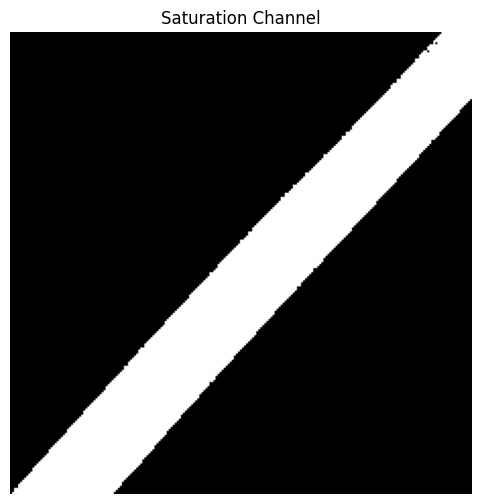

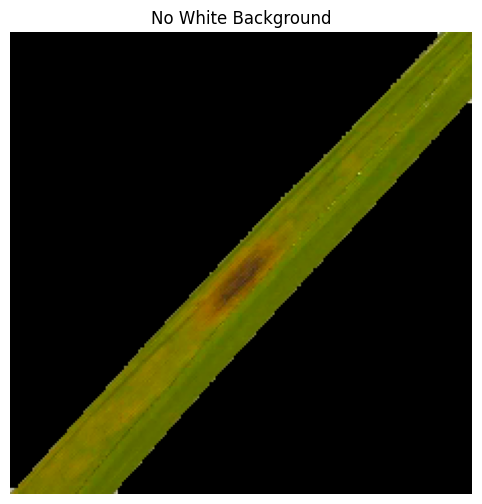

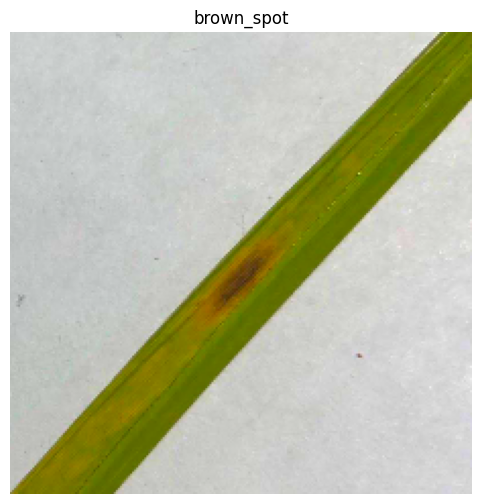

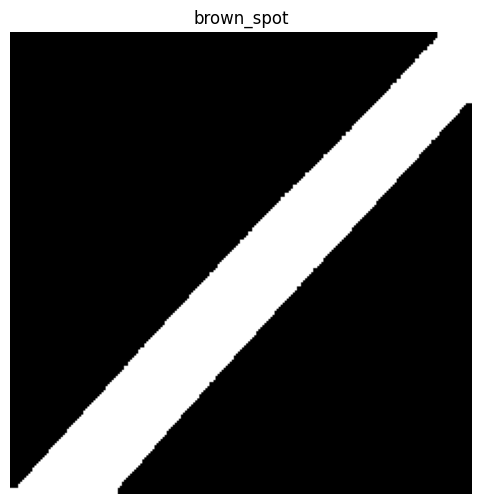

In [ ]:
IMG_SIZE = (227, 227)
label = 'healthy'
img = cv2.resize(cv2.imread('datasets/Malba_test_images/normal/IMG_5307.JPG'), IMG_SIZE)
print(img.shape)
segmented_image = segment_image(img, label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segmented_image, cmap='gray')
plt.axis('off') 
plt.title(label)

(227, 227, 3)


Text(0.5, 1.0, 'brown_spot')

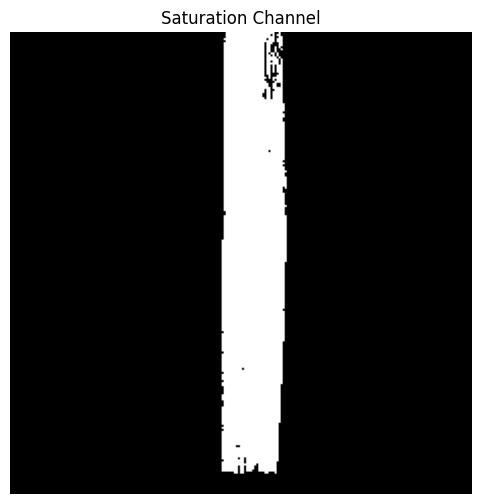

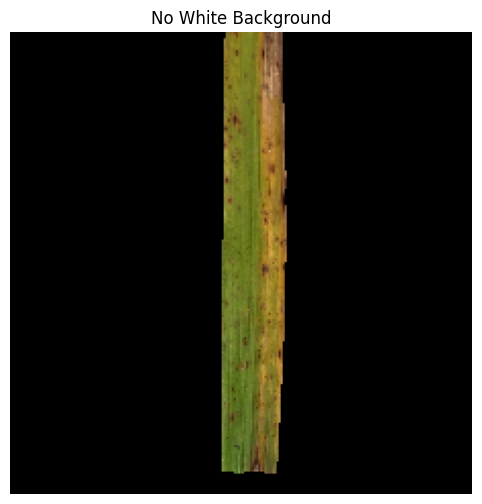

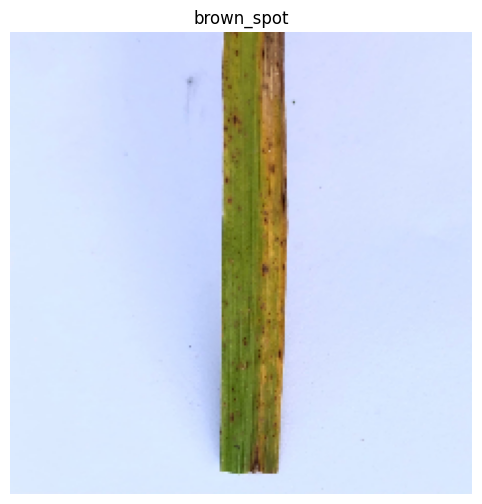

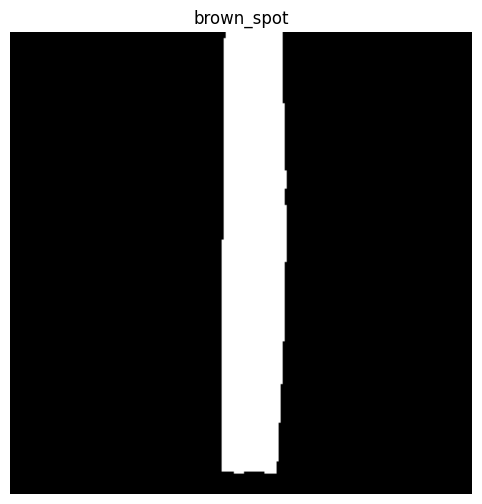

In [ ]:
IMG_SIZE = (227, 227)
label = 'brown_spot'
img = cv2.resize(cv2.imread('datasets/leaf-rice-disease-indonesia/tungro/IMG_0872.jpg'), IMG_SIZE)
print(img.shape)
segment_image2 = segment_image(img, label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off') 
plt.title(label)

fig = plt.figure(figsize=(9, 6))

plt.imshow(segment_image2, cmap='gray')
plt.axis('off') 
plt.title(label)